# Supply Chain Greenhouse Gas Emissions Analysis

## Objective

Analyze greenhouse gas emission factors across industries using SQL Server and Python.

### Dataset
- Source: SupplyChainCarbonDB
- Records: 1,016 industries
- Architecture:
    Bronze → Silver → Gold

This notebook performs exploratory data analysis (EDA) on the curated Gold layer.

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyodbc

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

In [53]:
from dotenv import load_dotenv
import os

load_dotenv()

SERVER = os.getenv("SQL_SERVER")
DATABASE = os.getenv("SQL_DATABASE")
DRIVER = os.getenv("SQL_DRIVER")

connection = pyodbc.connect(
    f"""
    Driver={{{DRIVER}}};
    Server={SERVER};
    Database={DATABASE};
    Trusted_Connection=yes;
    TrustServerCertificate=yes;
    """
)

print("✅ Connected Successfully!")

✅ Connected Successfully!


In [19]:
summary = pd.read_sql(
    "SELECT * FROM gold.vw_EmissionSummary",
    connection,
)

ranking = pd.read_sql(
    "SELECT * FROM gold.vw_IndustryRanking",
    connection,
)

contribution = pd.read_sql(
    "SELECT * FROM gold.vw_Contribution",
    connection,
)

categories = pd.read_sql(
    "SELECT * FROM gold.vw_EmissionCategories",
    connection,
)

In [20]:
summary

,Total_Industries,Avg_Emission,Max_Emission,Min_Emission,Std_Deviation
0,1016,0.39,10.99,0.01,0.57


In [21]:
ranking.head()

,NAICS_Code,Industry,Emission_With_Margins,Diff_From_Avg,Emission_Rank
0,562212,Solid Waste Landfill,10.99,10.60,1
1,327310,Cement Manufacturing,3.86,3.47,2
2,112111,Beef Cattle Ranching and Farming,3.30,2.91,3
3,112112,Cattle Feedlots,3.30,2.91,3
4,112130,Dual-Purpose Cattle Ranching and Farming,3.30,2.91,3


In [22]:
ranking.info()

<class 'pandas.DataFrame'>
RangeIndex: 1016 entries, 0 to 1015
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   NAICS_Code             1016 non-null   int64  
 1   Industry               1016 non-null   str    
 2   Emission_With_Margins  1016 non-null   float64
 3   Diff_From_Avg          1016 non-null   float64
 4   Emission_Rank          1016 non-null   int64  
dtypes: float64(2), int64(2), str(1)
memory usage: 39.8 KB


In [23]:
ranking.describe()

,NAICS_Code,Emission_With_Margins,Diff_From_Avg,Emission_Rank
count,1016.00,1016.00,1016.00,1016.00
mean,424917.38,0.39,0.00,178.78
std,164942.11,0.57,0.57,88.16
min,111110.00,0.01,-0.37,1.00
25%,325588.25,0.13,-0.26,99.75
50%,423700.00,0.21,-0.18,200.00
75%,532111.25,0.45,0.06,253.25
max,813990.00,10.99,10.60,308.00


In [24]:
ranking.isna().sum()

NAICS_Code               0
Industry                 0
Emission_With_Margins    0
Diff_From_Avg            0
Emission_Rank            0
dtype: int64

# Data Overview

This section provides a high-level overview of the curated Gold dataset used for analysis.

In [25]:
print(f"Rows    : {ranking.shape[0]}")
print(f"Columns : {ranking.shape[1]}")

Rows    : 1016
Columns : 5


### Key Findings

- The dataset contains 1,016 industry records.
- No missing values were found.
- The Gold layer is ready for analytical reporting.

# Distribution of Emission Factors

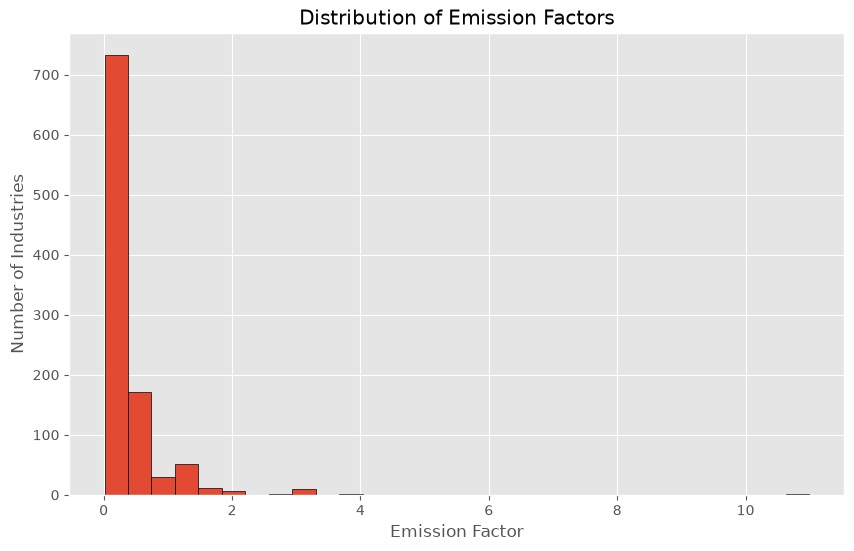

In [27]:
plt.figure(figsize=(10,6))

plt.hist(
    ranking["Emission_With_Margins"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Emission Factors")

plt.xlabel("Emission Factor")

plt.ylabel("Number of Industries")

plt.show()

### Observation

Most industries are concentrated within a relatively low emission range, while a small number of industries exhibit substantially higher emission factors, resulting in a right-skewed distribution.

### Insight

The emission factor distribution is highly right-skewed.

### Recommendation

Future analyses may segment industries into emission bands to support targeted sustainability planning.

# Outlier Detection

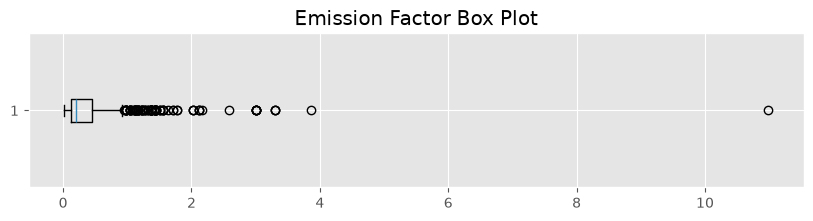

In [34]:
plt.figure(figsize=(10,2))

plt.boxplot(
    ranking["Emission_With_Margins"],
    orientation="horizontal"
)

plt.title("Emission Factor Box Plot")

plt.show()

### Observation

The box plot confirms the presence of several high-emission outliers. These industries warrant further investigation due to their disproportionate environmental impact.

### Insight

A limited number of industries contribute a disproportionately large share of total emissions.

### Recommendation

Further investigation of these industries could identify opportunities for high-impact carbon reduction strategies.

# Top 10 Industries by Emission Factor

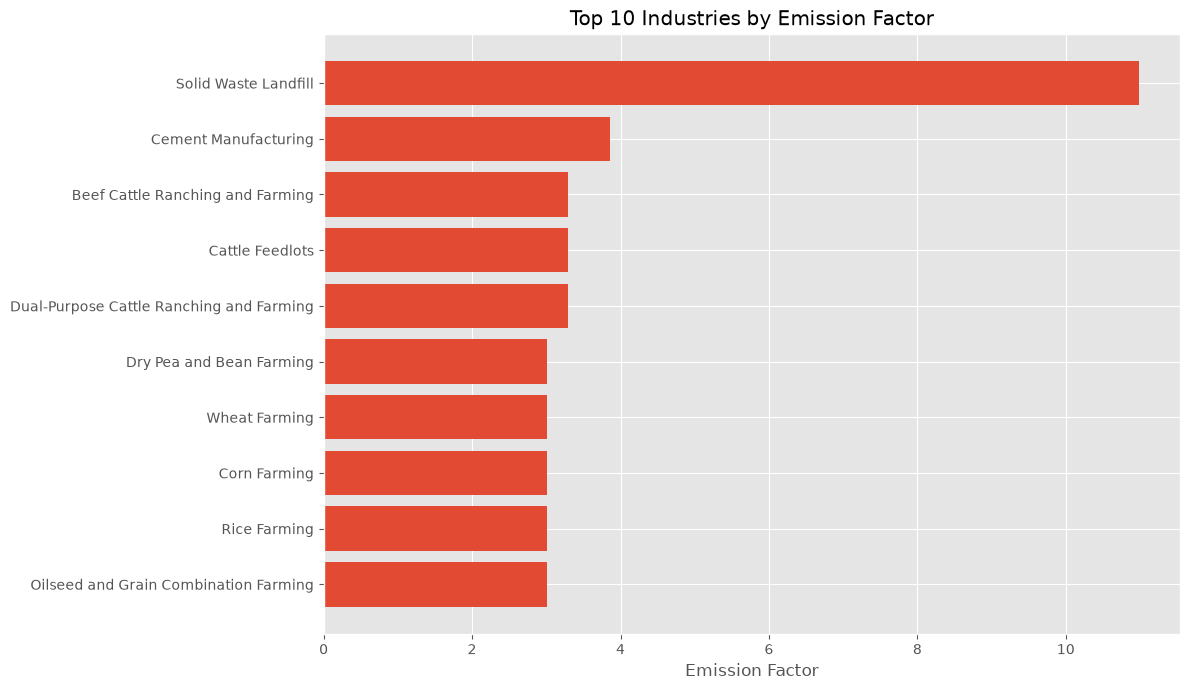

In [32]:
top10 = ranking.nlargest(
    10,
    "Emission_With_Margins"
)

plt.figure(figsize=(12,7))

plt.barh(
    top10["Industry"],
    top10["Emission_With_Margins"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Industries by Emission Factor")

plt.xlabel("Emission Factor")

plt.tight_layout()

plt.show()

### Observation

A relatively small group of industries dominates the highest emission factors, indicating potential priority areas for sustainability initiatives.

### Insight

A relatively small group of industries exhibits significantly higher emission factors than the rest of the dataset.

### Recommendation

Organizations may prioritize emission reduction initiatives within these industries to maximize environmental impact.

# Average Emission Factor by Emission Level

In [40]:
quartile_summary = (
    categories
    .groupby("Emission_Level")["Emission_With_Margins"]
    .mean()
    .reindex(["Very High", "High", "Medium", "Low"])
)

quartile_summary

Emission_Level
Very High   1.00
High        0.29
Medium      0.17
Low         0.09
Name: Emission_With_Margins, dtype: float64

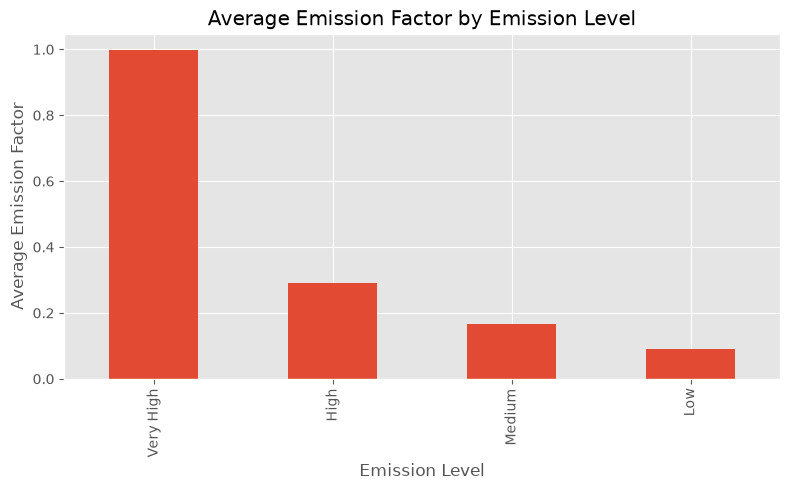

In [41]:
plt.figure(figsize=(8,5))

quartile_summary.plot(kind="bar")

plt.title("Average Emission Factor by Emission Level")
plt.xlabel("Emission Level")
plt.ylabel("Average Emission Factor")

plt.tight_layout()
plt.savefig("../images/emission_level_average.png", dpi=300)

plt.show()

In [56]:
# Compute top 10 contribution percentage
total_emissions = contribution["Emission_With_Margins"].sum()
top10_total = top10["Emission_With_Margins"].sum()
top10_pct = (top10_total / total_emissions) * 100

# Compute max vs average ratio
max_emission = ranking["Emission_With_Margins"].max()
avg_emission = ranking["Emission_With_Margins"].mean()
ratio = max_emission / avg_emission

# Very High category share
vh_mask = categories["Emission_Level"] == "Very High"
vh_count = vh_mask.sum()
vh_mean = categories.loc[vh_mask, "Emission_With_Margins"].mean()
vh_total = categories.loc[vh_mask, "Emission_With_Margins"].sum()
vh_share = (vh_total / total_emissions) * 100

print(f"Top 10 industries contribute {top10_pct:.1f}% of total emissions.")
print(f"Highest emitter (Solid Waste Landfill) is {ratio:.1f}x the industry average.")
print(f"Very High category ({vh_count} industries) accounts for {vh_share:.1f}% of emissions.")

Top 10 industries contribute 10.1% of total emissions.
Highest emitter (Solid Waste Landfill) is 28.5x the industry average.
Very High category (254 industries) accounts for 64.6% of emissions.


# Conclusion

## Key Findings

- Emission factors are highly right-skewed.
- A small number of industries account for a disproportionate share of emissions.
- High-emission industries should be prioritised for sustainability initiatives.
- Quartile classification provides a simple framework for industry benchmarking.